In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks as sp_find_peaks

from src.simulator import ULASimulator
from src.algorithms import Beamformer
from src.metrics import calculate_rmse

In [2]:
M             = 16
fc            = 3e9
TRUE_THETAS   = [10.0, 25.0]
NUM_SOURCES   = len(TRUE_THETAS)
SCAN_ANGLES   = np.linspace(-90, 90, 1801)
N_TRIALS      = 50
SNR_RANGE     = np.arange(-10, 25, 5)
SNAPSHOTS_RANGE = [16, 32, 64, 128, 256, 512, 1024]
FIXED_SNR     = 10
FIXED_SNAPSHOTS = 256
COLORS = {"das": "#4C72B0", "mvdr": "#DD8452", "music": "#55A868"}
LABELS = {"das": "DaS", "mvdr": "MVDR (Capon)", "music": "MUSIC"}

In [3]:
def to_db(s):
    s = np.array(s, dtype=float)
    s /= s.max()
    return 20 * np.log10(s + 1e-12)

def find_peaks_sorted(spectrum, scan_angles, num_peaks):
    peaks_idx, _ = sp_find_peaks(spectrum, distance=10)
    if len(peaks_idx) == 0:
        peaks_idx = np.argsort(spectrum)[-num_peaks:][::-1]
    else:
        peaks_idx = peaks_idx[np.argsort(spectrum[peaks_idx])[::-1]]
    return np.sort(scan_angles[peaks_idx[:num_peaks]])

def compute_rmse_point(snr_db, n_snapshots):
    sim = ULASimulator(M=M, fc=fc)
    bf  = Beamformer(sim)
    true_arr = np.array(sorted(TRUE_THETAS))
    rmse_das, rmse_mvdr, rmse_music = [], [], []
    for _ in range(N_TRIALS):
        X, _, _ = sim.generate_signal(TRUE_THETAS, snr_db=snr_db, n_snapshots=n_snapshots)
        R = bf.compute_covariance(X)
        for spectrum, bucket in [
            (bf.run_das(R, SCAN_ANGLES),                    rmse_das),
            (bf.run_mvdr(R, SCAN_ANGLES),                   rmse_mvdr),
            (bf.run_music(R, SCAN_ANGLES, NUM_SOURCES),     rmse_music),
        ]:
            est = find_peaks_sorted(spectrum, SCAN_ANGLES, NUM_SOURCES)
            bucket.append(np.sqrt(np.mean((est - true_arr) ** 2)))
    return float(np.mean(rmse_das)), float(np.mean(rmse_mvdr)), float(np.mean(rmse_music))

### Experiment 1 – RMSE vs SNR

In [4]:
res_snr = {"das": [], "mvdr": [], "music": []}
for snr in SNR_RANGE:
    d, m, mu = compute_rmse_point(snr, FIXED_SNAPSHOTS)
    res_snr["das"].append(d)
    res_snr["mvdr"].append(m)
    res_snr["music"].append(mu)
    print(f"SNR={snr:+3d} dB  DaS={d:.3f}°  MVDR={m:.3f}°  MUSIC={mu:.3f}°")

SNR=-10 dB  DaS=0.302°  MVDR=0.301°  MUSIC=0.319°
SNR= -5 dB  DaS=0.149°  MVDR=0.132°  MUSIC=0.122°
SNR= +0 dB  DaS=0.073°  MVDR=0.068°  MUSIC=0.060°
SNR= +5 dB  DaS=0.065°  MVDR=0.027°  MUSIC=0.027°
SNR=+10 dB  DaS=0.043°  MVDR=0.006°  MUSIC=0.004°
SNR=+15 dB  DaS=0.039°  MVDR=0.000°  MUSIC=0.000°
SNR=+20 dB  DaS=0.043°  MVDR=0.000°  MUSIC=0.000°


### Experiment 2 – RMSE vs N_snapshots

In [5]:
res_snap = {"das": [], "mvdr": [], "music": []}
for ns in SNAPSHOTS_RANGE:
    d, m, mu = compute_rmse_point(FIXED_SNR, ns)
    res_snap["das"].append(d)
    res_snap["mvdr"].append(m)
    res_snap["music"].append(mu)
    print(f"N={ns:4d}  DaS={d:.3f}°  MVDR={m:.3f}°  MUSIC={mu:.3f}°")

N=  16  DaS=0.234°  MVDR=0.765°  MUSIC=0.075°
N=  32  DaS=0.152°  MVDR=0.068°  MUSIC=0.047°
N=  64  DaS=0.118°  MVDR=0.035°  MUSIC=0.025°
N= 128  DaS=0.072°  MVDR=0.018°  MUSIC=0.011°
N= 256  DaS=0.042°  MVDR=0.003°  MUSIC=0.003°
N= 512  DaS=0.031°  MVDR=0.000°  MUSIC=0.000°
N=1024  DaS=0.021°  MVDR=0.000°  MUSIC=0.000°


### Figure 1 – RMSE curves

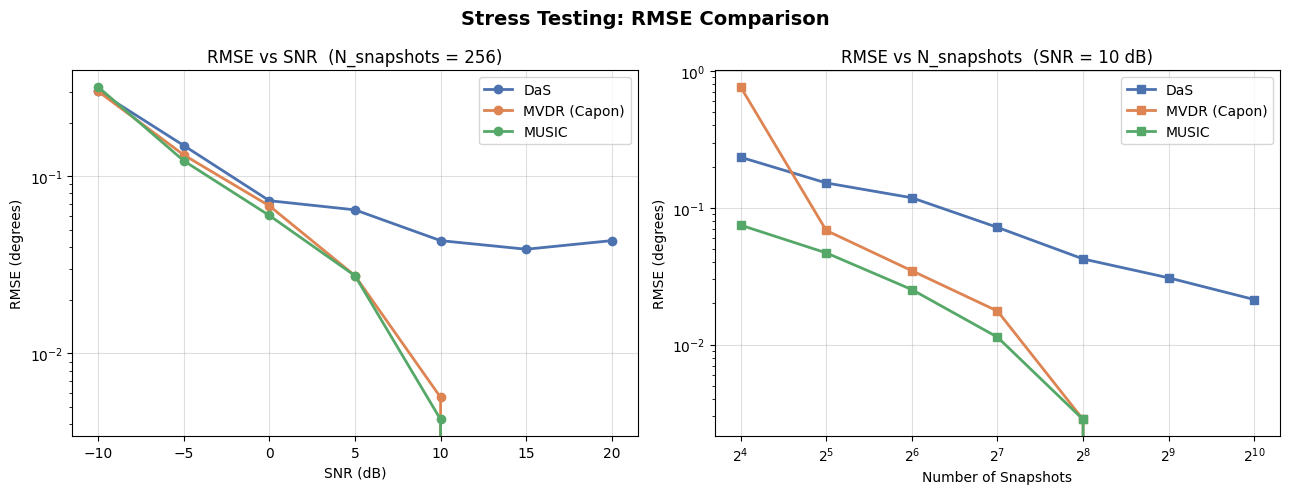

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Stress Testing: RMSE Comparison", fontsize=14, fontweight="bold")

ax = axes[0]
for key in ("das", "mvdr", "music"):
    ax.plot(SNR_RANGE, res_snr[key], "o-", color=COLORS[key], label=LABELS[key], linewidth=2)
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("RMSE (degrees)")
ax.set_title(f"RMSE vs SNR  (N_snapshots = {FIXED_SNAPSHOTS})")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.4)

ax = axes[1]
for key in ("das", "mvdr", "music"):
    ax.plot(SNAPSHOTS_RANGE, res_snap[key], "s-", color=COLORS[key], label=LABELS[key], linewidth=2)
ax.set_xlabel("Number of Snapshots")
ax.set_ylabel("RMSE (degrees)")
ax.set_title(f"RMSE vs N_snapshots  (SNR = {FIXED_SNR} dB)")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### Figure 2 – Spatial spectra (reference scenario)

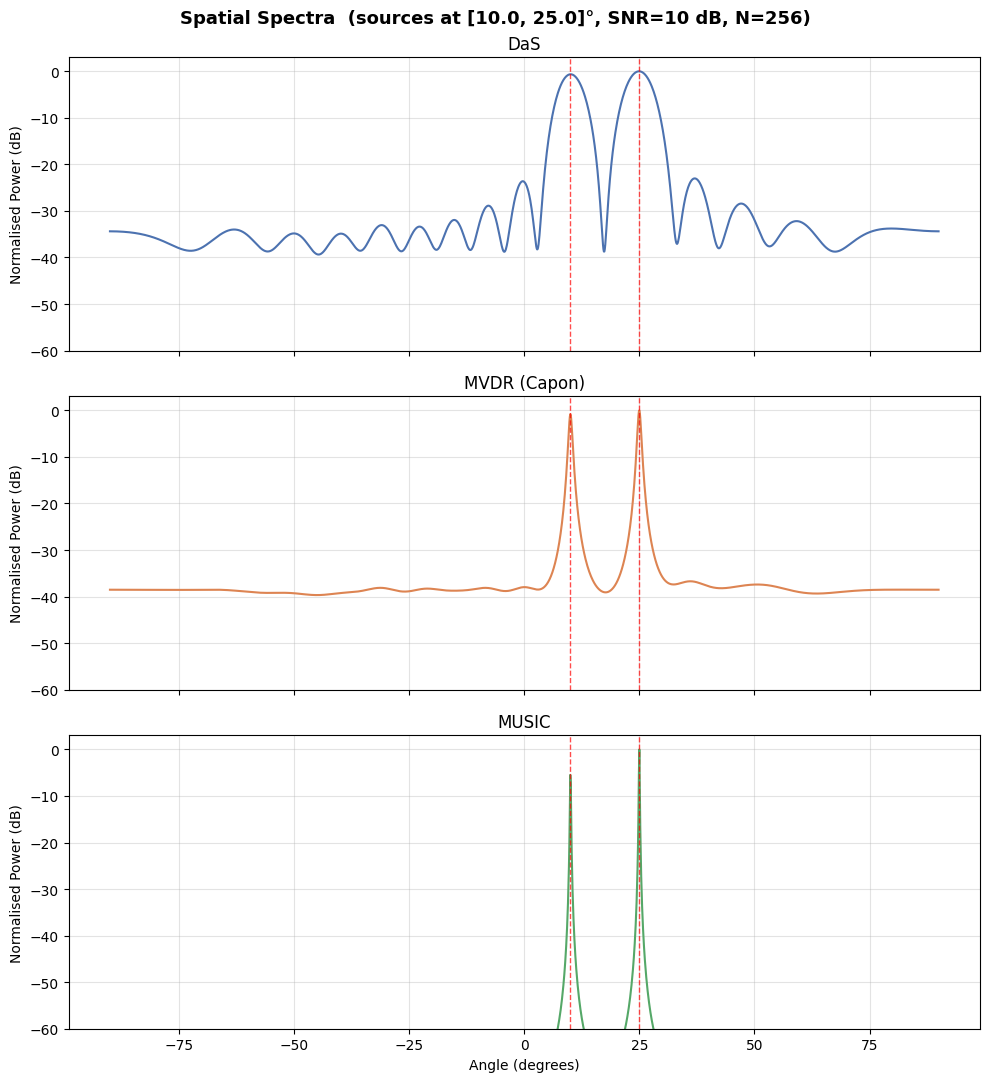

In [7]:
sim = ULASimulator(M=M, fc=fc)
bf  = Beamformer(sim)
X, _, _ = sim.generate_signal(TRUE_THETAS, snr_db=FIXED_SNR, n_snapshots=FIXED_SNAPSHOTS)
R = bf.compute_covariance(X)

spec_das   = bf.run_das(R, SCAN_ANGLES)
spec_mvdr  = bf.run_mvdr(R, SCAN_ANGLES)
spec_music = bf.run_music(R, SCAN_ANGLES, NUM_SOURCES)

fig2, axes2 = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
fig2.suptitle(f"Spatial Spectra  (sources at {TRUE_THETAS}°, SNR={FIXED_SNR} dB, N={FIXED_SNAPSHOTS})", fontsize=13, fontweight="bold")

for ax, spec, key in zip(axes2, [spec_das, spec_mvdr, spec_music], ["das", "mvdr", "music"]):
    ax.plot(SCAN_ANGLES, to_db(spec), color=COLORS[key], linewidth=1.5)
    for theta in TRUE_THETAS:
        ax.axvline(theta, color="red", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_ylabel("Normalised Power (dB)")
    ax.set_title(LABELS[key])
    ax.set_ylim(-60, 3)
    ax.grid(True, alpha=0.35)

axes2[-1].set_xlabel("Angle (degrees)")
plt.tight_layout()
plt.show()

### Figure 3 – Spatial spectra across SNR levels

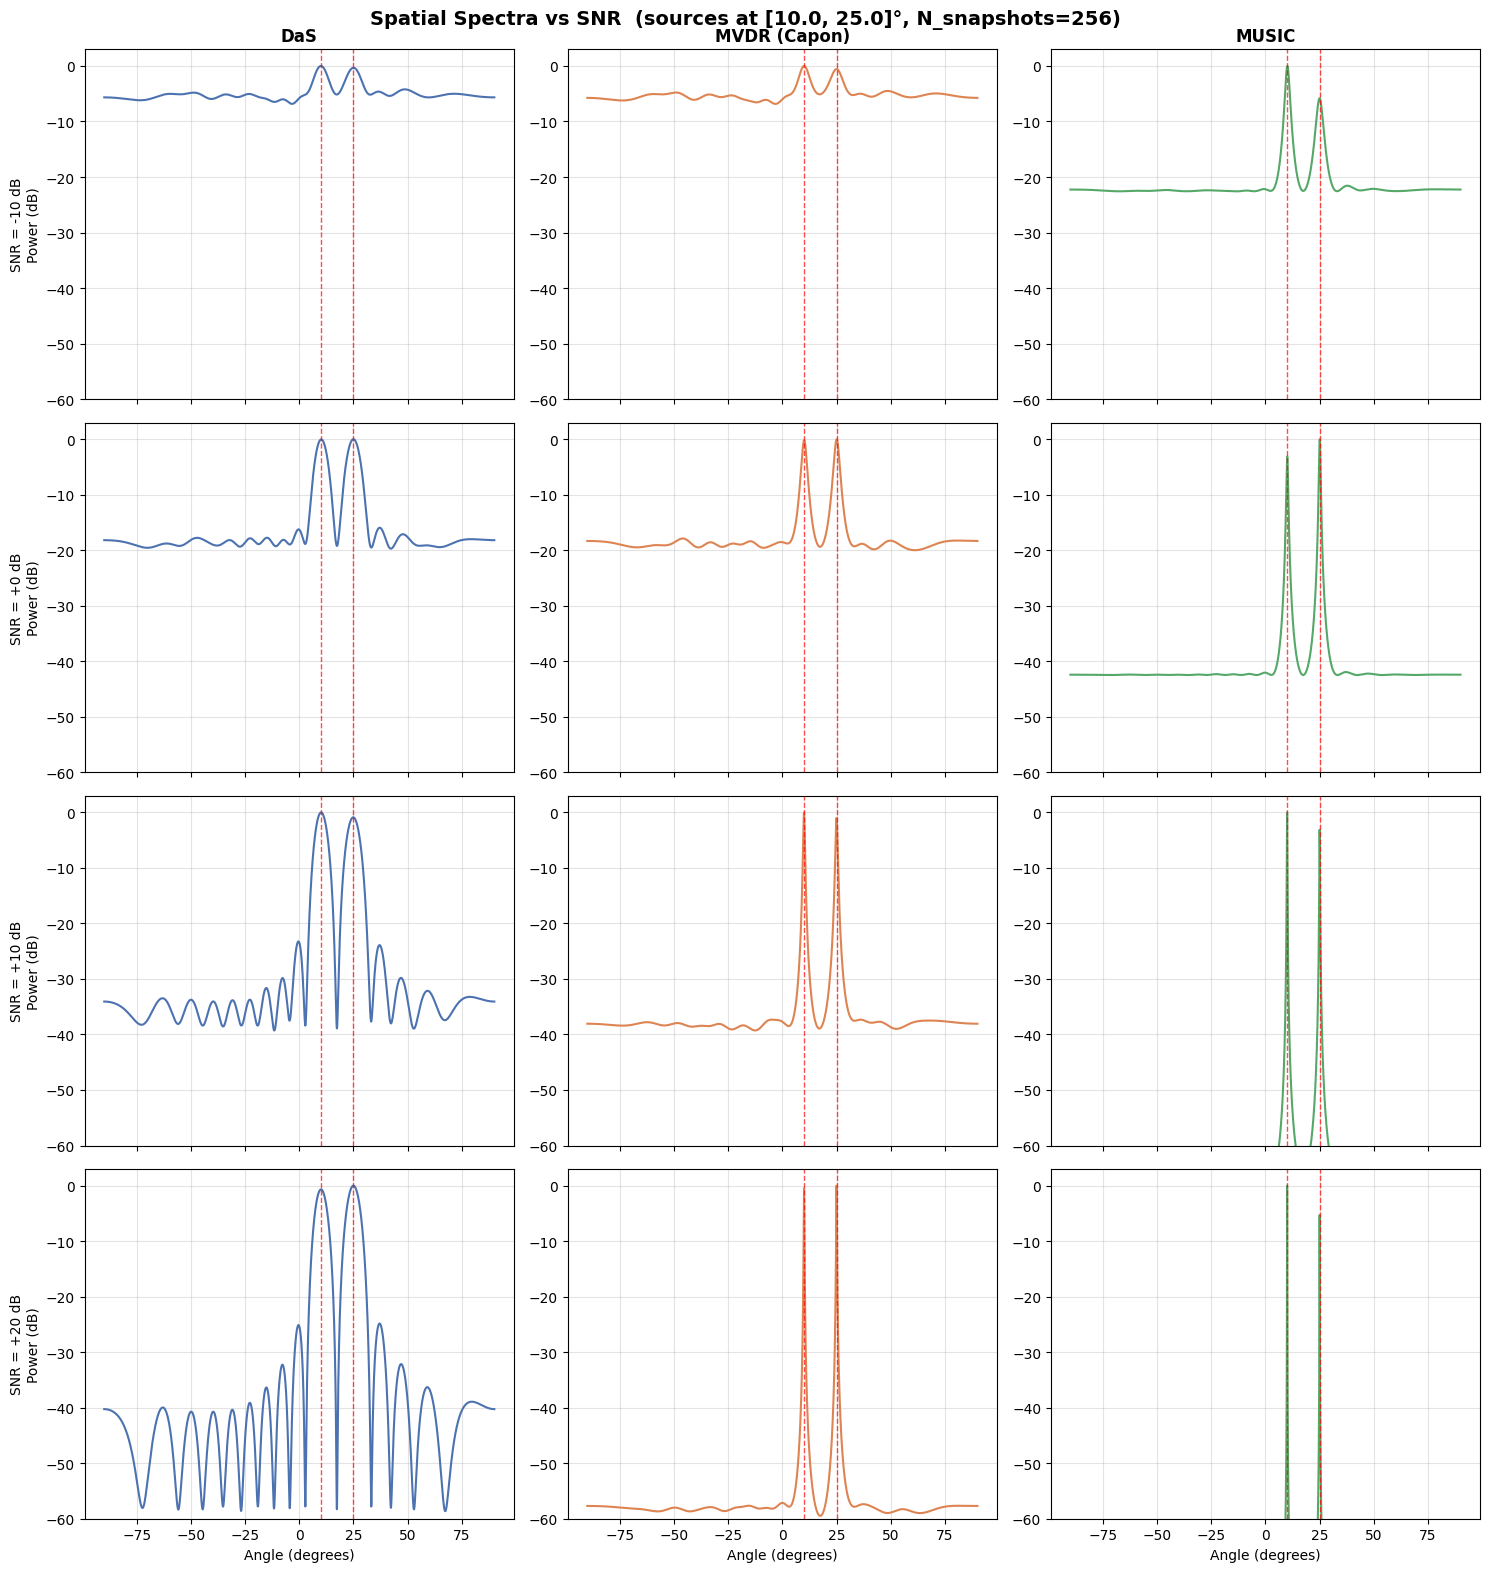

In [8]:
SNR_VISUAL = [-10, 0, 10, 20]

fig3, axes3 = plt.subplots(len(SNR_VISUAL), 3, figsize=(15, 4 * len(SNR_VISUAL)), sharex=True)
fig3.suptitle(f"Spatial Spectra vs SNR  (sources at {TRUE_THETAS}°, N_snapshots={FIXED_SNAPSHOTS})", fontsize=14, fontweight="bold")

col_keys = ["das", "mvdr", "music"]

for row_idx, snr in enumerate(SNR_VISUAL):
    sim_v = ULASimulator(M=M, fc=fc)
    bf_v  = Beamformer(sim_v)
    X_v, _, _ = sim_v.generate_signal(TRUE_THETAS, snr_db=snr, n_snapshots=FIXED_SNAPSHOTS)
    R_v = bf_v.compute_covariance(X_v)
    spectra_v = {
        "das":   bf_v.run_das(R_v, SCAN_ANGLES),
        "mvdr":  bf_v.run_mvdr(R_v, SCAN_ANGLES),
        "music": bf_v.run_music(R_v, SCAN_ANGLES, NUM_SOURCES),
    }
    for col_idx, key in enumerate(col_keys):
        ax = axes3[row_idx, col_idx]
        ax.plot(SCAN_ANGLES, to_db(spectra_v[key]), color=COLORS[key], linewidth=1.5)
        for theta in TRUE_THETAS:
            ax.axvline(theta, color="red", linestyle="--", linewidth=1, alpha=0.7)
        ax.set_ylim(-60, 3)
        ax.grid(True, alpha=0.35)
        if row_idx == 0:
            ax.set_title(LABELS[key], fontsize=12, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(f"SNR = {snr:+d} dB\nPower (dB)", fontsize=10)
        if row_idx == len(SNR_VISUAL) - 1:
            ax.set_xlabel("Angle (degrees)")

plt.tight_layout()
plt.show()